In [1]:
import pandas as pd

In [2]:
from pathlib import Path

In [3]:
class Bucket:
    def __init__(self, start, end, label):
        self.start = start
        self.end = end
        self.label = label
        self.value = self._compute_value() 

    def __contains__(self, item):
        return item >= self.start and item < self.end

    def _compute_value(self):
        mid = (self.end + self.start) / 2
        v = self.start + mid if abs(self.end) < abs(self.start) else self.end + mid
        return round(v)

buckets_with_labels = [(-34, -21, "NJ"), (-21, -13, "NI"), (-13, -8, "NH"), (-8, -5, "NG"), (-5, -3, "NF"), (-3, -2, "NE"),  (-2, -1.5, "ND"), (-1.5, -1, "NC"), (-1, -0.5, "NB"), (-0.5, 0, "NA"), 
 (0, 0.5, "PA"), (0.5, 1, "PB"), (1, 1.5, "PC"), (1.5, 2, "PD"), (2, 3, "PE"), (3, 5, "PF"), (5, 8, "PG"), (8, 13, "PH"), (13, 21, "PI"), (21, 34, "PJ")]

buckets = []

for (s, e, l) in buckets_with_labels:
    bucket = Bucket(s, e, l)
    buckets.append(bucket)

def label_for_value(value):
    for b in buckets:
        if value in b:
            return b.label

In [4]:
series = []
for file in Path("Nifty50HistoricalData").glob("*.csv"):
    df = pd.read_csv(file)
    df['Change'] = (df['Close '] - df['Open ']) / df['Open '] * 100
    df['Label'] = df['Change'].apply(label_for_value)
    series += df['Label'].tolist()

In [5]:
tokens = [b.label for b in buckets]

In [6]:
tokens

['NJ',
 'NI',
 'NH',
 'NG',
 'NF',
 'NE',
 'ND',
 'NC',
 'NB',
 'NA',
 'PA',
 'PB',
 'PC',
 'PD',
 'PE',
 'PF',
 'PG',
 'PH',
 'PI',
 'PJ']

In [7]:
token_to_value = {l:v for (l,v) in [(b.label, b.value) for b in buckets]}

In [8]:
value_to_token = { v:l for l,v in token_to_value.items() }

In [9]:
value_to_token

{-62: 'NJ',
 -38: 'NI',
 -24: 'NH',
 -14: 'NG',
 -9: 'NF',
 -6: 'NE',
 -4: 'ND',
 -3: 'NC',
 -2: 'NB',
 -1: 'NA',
 1: 'PA',
 2: 'PB',
 3: 'PC',
 4: 'PD',
 6: 'PE',
 9: 'PF',
 14: 'PG',
 24: 'PH',
 38: 'PI',
 62: 'PJ'}

In [10]:
token_to_value

{'NJ': -62,
 'NI': -38,
 'NH': -24,
 'NG': -14,
 'NF': -9,
 'NE': -6,
 'ND': -4,
 'NC': -3,
 'NB': -2,
 'NA': -1,
 'PA': 1,
 'PB': 2,
 'PC': 3,
 'PD': 4,
 'PE': 6,
 'PF': 9,
 'PG': 14,
 'PH': 24,
 'PI': 38,
 'PJ': 62}

In [11]:
import matplotlib.pyplot as plt
import numpy as np

In [12]:
ys = list(map(lambda x: token_to_value[x], series[:30]))

In [13]:
xs = np.arange(0, len(ys))

<BarContainer object of 30 artists>

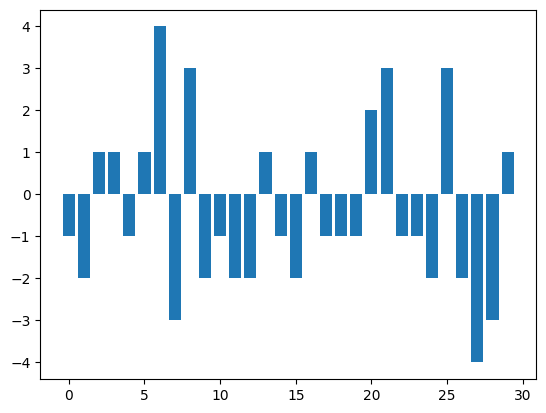

In [14]:
plt.bar(xs, ys)

In [15]:
import pandas as pd
import random
import torch
from torch import nn
import tiktoken
from torch.utils.data import Dataset, DataLoader
import os
from datetime import datetime

In [16]:
class Tokenizer:
    def __init__(self, vocab):
        self.vocab = vocab

    def encode(self, text):
        tokens = []
        for i in range(0, len(text)-1, 2):
            tokens.append(text[i:i+2])
            
        return [self.vocab.index(tok) for tok in tokens]

    def decode(self, encodings):
        return "".join([self.vocab[enc] for enc in encodings])

In [17]:
series[:10]

['NA', 'NB', 'PA', 'PA', 'NA', 'PA', 'PD', 'NC', 'PC', 'NB']

In [18]:
tokenizer = Tokenizer(sorted(tokens))

In [19]:
''.join(series[:10])

'NANBPAPANAPAPDNCPCNB'

In [20]:
tokenizer.encode(''.join(series[:10]))

[0, 1, 10, 10, 0, 10, 13, 2, 12, 1]

In [21]:
tokenizer.decode([0, 1, 10, 10, 0, 10, 13, 2, 12, 1])

'NANBPAPANAPAPDNCPCNB'

In [22]:
GPT_CONFIG = {
    "vocab_size": len(tokenizer.vocab),
    "context_length": 30, # use a shorter context length
    "emb_dim": 64,
    "n_heads": 8,
    "n_layers": 12,
    "drop_rate": 0.1,
    "qkv_bias": False
}

In [23]:
class GPTDataSet(Dataset):
    def __init__(self, text, tokenizer, context_length, stride):
        self.input_ids = []
        self.target_ids = []

        encodings = tokenizer.encode(text)            

        for i in range(0, len(encodings) - context_length, stride):
            inputs = encodings[i:i+context_length]
            targets = encodings[i+1:i+context_length+1]
            self.input_ids.append(torch.tensor(inputs))
            self.target_ids.append(torch.tensor(targets))

    def __len__(self):
        return len(self.input_ids)

    def __getitem__(self, idx):
        return self.input_ids[idx], self.target_ids[idx]

In [24]:
def create_data_loader(text, tokenizer, batch_size=8, context_length=6, stride=3, shuffle=True, drop_last=True):
    dataset = GPTDataSet(text, tokenizer, context_length, stride)
    n_cpus = os.cpu_count()
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle, drop_last=drop_last, num_workers=n_cpus)

In [139]:
class GPTTrainer:
    def __init__(self, model, train_dataloader, validation_dataloader, optimizer, tokenizer, device):
        self.model = model
        self.train_dataloader = train_dataloader
        self.validation_dataloader = validation_dataloader
        self.optimizer = optimizer
        self.tokenizer = tokenizer
        self.device = device
        self.epoches = 10
        self.eval_freq = 1000
        self.eval_iter = 5
        self.top_k = None
        self.temperature = 0.0
        self.eos_id = None

    def set_epoches(self, value):
        self.epoches = value

    def set_eval_freq(self, value):
        self.eval_freq = value

    def set_eval_iter(self, value):
        self.eval_iter = value

    def set_topk(self, value):
        self.top_k = value

    def set_temperature(self, value):
        self.temperature = value

    def set_eos_id(value):
        self.eos_id = value

    def train(self, start_context):
        train_lossess, val_lossess, track_tokens_seen = [], [], []
        tokens_seen, global_step = 0, -1
        
        for epoch in range(self.epoches):
            model.train()
            for input_batch, target_batch in train_loader:
                optimizer.zero_grad()
                loss = self.calc_batch_loss(input_batch, target_batch)
                loss.backward()
                optimizer.step()
                tokens_seen += input_batch.numel()
                global_step += 1
    
                if global_step % self.eval_freq == 0:
                    train_loss, val_loss = self.evaluate_model(self.eval_iter)
                    train_lossess.append(train_loss)
                    val_lossess.append(val_loss)
                    track_tokens_seen.append(tokens_seen)
                    print(f"Epoch {epoch+1} (Step {global_step:06d}): "
                          f"Train loss {train_loss:.3f}, "
                          f"Val loss {val_loss:.3f}"
                    )
        self.generate_and_print_sample(start_context, no_samples=10)
        self.train_lossess = train_lossess
        self.val_lossess = val_lossess
        self.track_tokens_seen = track_tokens_seen
        return train_lossess, val_lossess, track_tokens_seen

    def evaluate_model(self, eval_iter):
        model.eval()
        with torch.no_grad():
            train_loss = self.calc_loss_loader(
                self.train_dataloader, num_batches=eval_iter
            )
            val_loss = self.calc_loss_loader(
                self.validation_dataloader, num_batches=eval_iter
            )
        model.train()
        return train_loss, val_loss

    def generate_and_print_sample(self, start_context, no_samples=1):
        model.eval()
        context_size = self.model.pos_embedding.weight.shape[0]
            
        with torch.no_grad():
            for _ in range(no_samples):
                encoded = self.text_to_token_ids(start_context).to(self.device)    
                token_ids = self.generate(idx=encoded, max_new_tokens=10)
                decoded_text = self.token_ids_to_text(token_ids)
                print(decoded_text)
        model.train()

    def text_to_token_ids(self, start_context):
        encoded = self.tokenizer.encode(start_context)
        encoded_tensor = torch.tensor(encoded).unsqueeze(0)
        return encoded_tensor

    def token_ids_to_text(self, token_ids):
        flat = token_ids.squeeze(0)
        return self.tokenizer.decode(flat.tolist())

    # def generate_sample(self, idx, max_new_tokens):
    #     context_size = self.model.pos_embedding.weight.shape[0]
        
    #     for _ in range(max_new_tokens):
    #         idx_cond = idx[:, -context_size:]
    #         with torch.no_grad():
    #             logits = model(idx_cond)
    #             logits = logits[:, -1, :]
    #             probs = torch.softmax(logits, dim=-1)
    #             idx_next = torch.argmax(probs, dim=-1, keepdim=True)
    #             idx = torch.cat((idx, idx_next), dim=1)
                
    #             if (idx_next.item() == 0):
    #                 break
    
    #     return idx
        
    def generate(self, idx, max_new_tokens):
        context_size = self.model.pos_embedding.weight.shape[0]

        for _ in range(max_new_tokens):
            idx_cond = idx[:, -context_size:]
            with torch.no_grad():
                logits = model(idx_cond)
                logits = logits[:, -1, :]
                if self.top_k is not None:
                    top_logits, _ = torch.topk(logits, self.top_k)
                    min_value = top_logits[:, -1]
                    logits = torch.where(logits < min_value, torch.tensor(float('-inf')).to(logits.device), logits)

                if self.temperature > 0.0:
                    logits = logits / self.temperature
                    probs = torch.softmax(logits, dim=-1)
                    idx_next = torch.multinomial(probs, num_samples=1)
                else:
                    idx_next = torch.argmax(logits, dim=-1, keepdim=True)

                if idx_next == self.eos_id:
                    break
                
                idx = torch.cat((idx, idx_next), dim=1)
        return idx

    def calc_batch_loss(self, input_batch, target_batch):
        input_batch = input_batch.to(self.device)
        target_batch = target_batch.to(self.device)
        logits = self.model(input_batch)
        loss = nn.functional.cross_entropy(logits.flatten(0, 1), target_batch.flatten())
        return loss

    def calc_loss_loader(self, data_loader, num_batches=None):
        total_loss = 0
        if len(data_loader) == 0:
            return float("nan")
        elif num_batches is None:
            num_batches = len(data_loader)
        else:
            num_batches = min(num_batches, len(data_loader))
    
        for i, (input_batch, target_batch) in enumerate(data_loader):
            if i < num_batches:
                loss = self.calc_batch_loss(input_batch, target_batch)
                total_loss += loss.item()
            else:
                break
    
        return total_loss / num_batches


In [140]:
def prepare_dataset(cfg, text):
    train_ratio = 0.9
    split_idx = int(train_ratio * len(text))
    if (split_idx % 2) != 0:
        split_idx += 1
    train_data = text[:split_idx]
    val_data = text[split_idx:]
    
    train_loader = create_data_loader(train_data, tokenizer, batch_size=8, context_length=cfg['context_length'])
    val_loader = create_data_loader(val_data, tokenizer, batch_size=8, context_length=cfg['context_length'])
    return train_loader, val_loader

In [141]:
train_loader, val_loader = prepare_dataset(GPT_CONFIG, ''.join(series))

In [142]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [143]:
from gpt import GPTModel
model = GPTModel(GPT_CONFIG)
model.to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=0.0004, weight_decay=0.1)

In [144]:
# num_epoches = 10
# train_losses, val_lossess, tokens_seen = train_model_simple(
#     model, train_loader, val_loader, optimizer, device, num_epoches=num_epoches, eval_freq=1000, eval_iter=5,
#     start_context= ['NA', 'NB', 'PA', 'PA', 'NA', 'PA', 'PD', 'NC', 'PC', 'NB'], tokenizer=tokenizer
# )

In [154]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

def plot_lossess(epoches_seen, tokens_seen, train_lossess, val_lossess):
    fig, ax1 = plt.subplots(figsize=(5,3))
    ax1.plot(epoches_seen, train_lossess, label="Training loss")
    ax1.plot(
        epoches_seen, val_lossess, linestyle="-.", label="Validation loss"
    )
    ax1.set_xlabel("Epoches")
    ax1.set_ylabel("Loss")
    ax1.legend(loc="upper right")
    ax1.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax2 = ax1.twiny()
    ax2.plot(tokens_seen, train_lossess, alpha=0)
    ax2.set_xlabel("Tokens seen")
    fig.tight_layout()
    plt.show()

In [146]:
trainer = GPTTrainer(model, train_loader, val_loader, optimizer, tokenizer, device)

In [148]:
trainer.set_epoches(10)
trainer.set_topk(5)
trainer.set_temperature(1.4)
trainer.train("PA")

Epoch 1 (Step 000000): Train loss 2.126, Val loss 2.256
Epoch 5 (Step 001000): Train loss 2.009, Val loss 2.207
Epoch 9 (Step 002000): Train loss 1.705, Val loss 2.345
PAPANBPANANBPBNANAPANA
PAPBNBPANBPBNANAPCNCNC
PAPCNBPANBNANAPAPAPAPA
PAPAPCNBNANAPAPBPAPANB
PAPCNAPCPCNCNCNBNAPAPA
PAPBNBNCNANAPBNBNANANA
PAPBNBNCPAPAPBPANCPAPB
PAPBNAPBNBNANAPBNANBNA
PAPBPBPBNBNBNANAPCNANC
PANANANANBPAPBPAPCPANC


([2.125839352607727, 2.0094610691070556, 1.7052475929260253],
 [2.255681943893433, 2.2074427604675293, 2.344799041748047],
 [240, 240240, 480240])

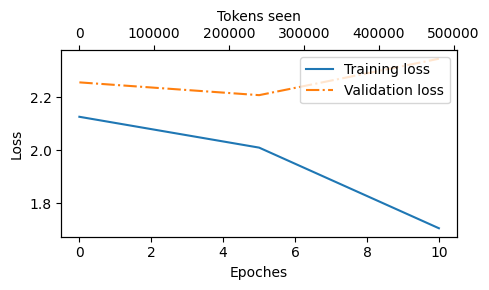

In [155]:
epoch_tensor = torch.linspace(0, trainer.epoches, len(trainer.train_lossess))
plot_lossess(epoch_tensor, trainer.track_tokens_seen, trainer.train_lossess, trainer.val_lossess)

In [94]:
logits = torch.tensor([[ 2.8355,  2.1061,  1.1759, -0.1172, -0.2549, -1.2079, -2.9981, -5.1166,
         -5.2998, -4.9549,  2.8855,  2.3540,  1.6712,  0.9683,  0.1338, -1.4652,
         -2.8249, -5.3576, -4.4073, -6.1917]], device='cuda:0')

In [97]:
torch.topk(logits, 5)

torch.return_types.topk(
values=tensor([[2.8855, 2.8355, 2.3540, 2.1061, 1.6712]], device='cuda:0'),
indices=tensor([[10,  0, 11,  1, 12]], device='cuda:0'))

In [96]:
logits.shape

torch.Size([1, 20])